In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammetvarl/laptop-price/laptop_price.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [4]:
df = pd.read_csv("/kaggle/input/datasets/muhammetvarl/laptop-price/laptop_price.csv",encoding='latin-1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [5]:
df.dtypes

laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object

In [8]:
df.isna().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [10]:
# Ram column has 'GB' units, should be numeric
df['Ram'].head()

0     8GB
1     8GB
2     8GB
3    16GB
4     8GB
Name: Ram, dtype: object

In [11]:
# Fix Ram column (remove GB and convert to numeric)
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Ram'] = pd.to_numeric(df['Ram'])
df['Ram'].head()


0     8
1     8
2     8
3    16
4     8
Name: Ram, dtype: int64

In [12]:
# Fix Weight column (remove kg and convert to numeric)
df['Weight'] = df['Weight'].str.replace('kg', '')
df['Weight'] = pd.to_numeric(df['Weight'])
df['Weight'].head()

0    1.37
1    1.34
2    1.86
3    1.83
4    1.37
Name: Weight, dtype: float64

In [13]:
df2 = df.copy()
df2['Price_euros'].fillna(df2['Price_euros'].median(), inplace=True)

/tmp/ipykernel_55/2039081547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Price_euros'].fillna(df2['Price_euros'].median(), inplace=True)


In [14]:
print("Used median imputation because median is robust to outliers")

Used median imputation because median is robust to outliers


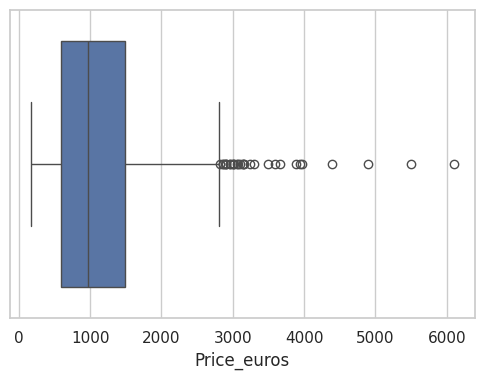

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df2['Price_euros'])
plt.show()

In [16]:
Q1 = df2['Price_euros'].quantile(0.25)
Q3 = df2['Price_euros'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df2[(df2['Price_euros'] < lower) | (df2['Price_euros'] > upper)]
outliers.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
17,18,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16,512GB SSD,AMD Radeon Pro 560,macOS,1.83,2858.0
190,194,Lenovo,Thinkpad Yoga,2 in 1 Convertible,14.0,Touchscreen 2560x1440,Intel Core i7 7500U 2.7GHz,16,1TB SSD,Intel HD Graphics 620,Windows 10,1.42,2824.0
196,200,Razer,Blade Pro,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49,6099.0
204,208,Dell,Precision 7520,Workstation,15.6,4K Ultra HD 3840x2160,Intel Xeon E3-1505M V6 3GHz,16,256GB SSD + 1TB HDD,Nvidia Quadro M1200,Windows 10,2.80,3055.0
238,243,Asus,ROG G703VI-E5062T,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,32,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1080,Windows 10,4.70,3890.0


In [ ]:
df_no_outliers = df2[(df2['Price_euros'] >= lower) & (df2['Price_euros'] <= upper)]

print('df with outliers:', df2.shape)
print('df without outliers:', df_no_outliers.shape)

df with outliers: (1303, 13)
df without outliers: (1274, 13)


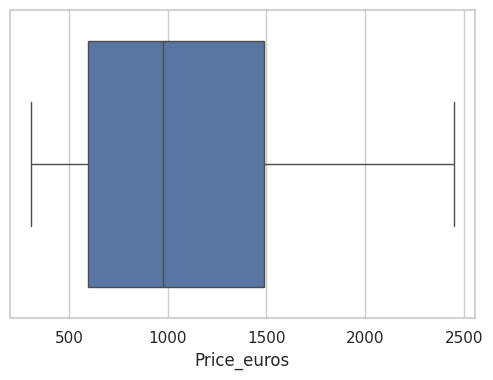

In [18]:
lower_cap = df2['Price_euros'].quantile(0.05)
upper_cap = df2['Price_euros'].quantile(0.95)

df_capped = df2.copy()
df_capped['Price_euros'] = df_capped['Price_euros'].clip(lower_cap, upper_cap)

plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['Price_euros'])
plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_capped[['Inches', 'Ram', 'Weight', 'Price_euros']].copy()
df_scaled = scaler.fit_transform(df_scaled)
df_scaled = pd.DataFrame(df_scaled, columns=['Inches', 'Ram', 'Weight', 'Price_euros'])
df_scaled.head()

,Inches,Ram,Weight,Price_euros
0,0.385542,0.096774,0.169576,0.481721
1,0.385542,0.096774,0.162095,0.275724
2,0.662651,0.096774,0.291771,0.124322
3,0.638554,0.225806,0.284289,1.000000
4,0.385542,0.096774,0.169576,0.698542


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_capped[['Inches', 'Ram', 'Weight', 'Price_euros']].copy()
df_standardized = scaler.fit_transform(df_standardized)
df_standardized = pd.DataFrame(df_standardized, columns=['Inches', 'Ram', 'Weight', 'Price_euros'])
df_standardized.head()

,Inches,Ram,Weight,Price_euros
0,-1.204407,-0.075195,-1.005283,0.396088
1,-1.204407,-0.075195,-1.050381,-0.327465
2,0.408772,-0.075195,-0.268684,-0.859257
3,0.268495,1.498767,-0.313782,2.216519
4,-1.204407,-0.075195,-1.005283,1.157661


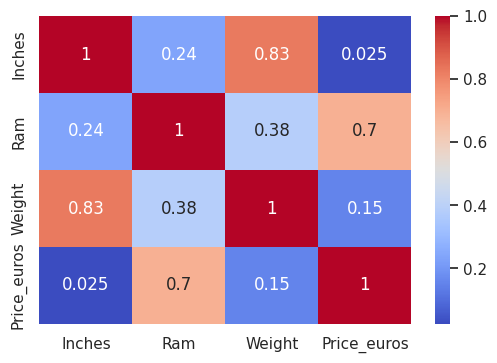

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized.corr(), annot=True, cmap="coolwarm")
plt.show()

In [22]:
from sklearn.decomposition import PCA

X = df_standardized

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.54669269 0.34658714]


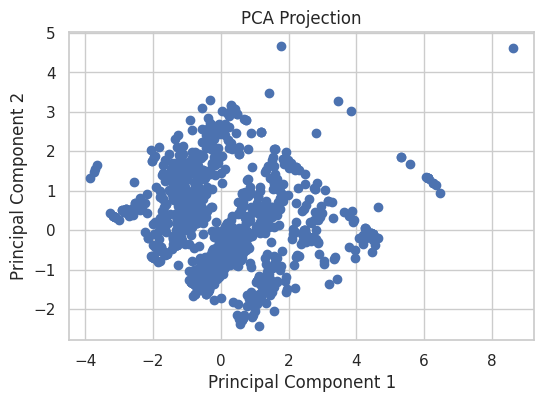

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()